# 📊 Análise Estatística Completa - Notebook Consolidado

## Implementação dos Requisitos do README

Este notebook implementa todas as análises estatísticas solicitadas:

1. **Estatísticas Descritivas** (média, mediana, moda, amplitude, variância, desvio padrão)
2. **Análises de Correlação** (Pearson e Spearman)
3. **Técnicas de Amostragem** (simples, sistemática, estratificada, conglomerados)
4. **Teorema do Limite Central** com diferentes tamanhos de amostra
5. **Análise de Distribuições** usando Python Fitter

---

## 🔧 Configuração do Ambiente

In [1]:
# Importações necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Verificar bibliotecas opcionais
try:
    from fitter import Fitter, get_common_distributions
    FITTER_AVAILABLE = True
    print('✅ Python Fitter disponível')
except ImportError:
    FITTER_AVAILABLE = False
    print('⚠️ Python Fitter não encontrado (pip install fitter)')

print('📦 Ambiente configurado com sucesso!')
print(f'🐍 Pandas: {pd.__version__}')
print(f'🔢 NumPy: {np.__version__}')
print(f'📊 Matplotlib: {plt.matplotlib.__version__}')
print(f'🎨 Seaborn: {sns.__version__}')

✅ Python Fitter disponível
📦 Ambiente configurado com sucesso!
🐍 Pandas: 2.3.3
🔢 NumPy: 1.26.4
📊 Matplotlib: 3.10.6
🎨 Seaborn: 0.13.2


## 📂 Carregamento dos Dados

In [2]:
# Carregar dados
try:
    # Tentar carregar o arquivo principal
    df = pd.read_csv('../data/datatran_consolidado.csv')
    print(f'✅ Dados carregados: {df.shape[0]:,} linhas x {df.shape[1]} colunas')
except FileNotFoundError:
    print('⚠️ Arquivo principal não encontrado. Gerando dados sintéticos...')
    
    # Gerar dados sintéticos para demonstração
    np.random.seed(42)
    n_samples = 10000
    
    df = pd.DataFrame({
        'TOTAL_MORTOS': np.random.poisson(0.5, n_samples),
        'TOTAL_FERIDOS': np.random.poisson(2.3, n_samples),
        'TOTAL_ILESOS': np.random.poisson(8.7, n_samples),
        'GRAVIDADE': np.random.choice([1, 2, 3, 4], n_samples, p=[0.4, 0.3, 0.2, 0.1]),
        'ESTADO': np.random.choice(['SP', 'RJ', 'MG', 'RS', 'PR'], n_samples),
        'REGIAO': np.random.choice(['Sudeste', 'Sul', 'Nordeste'], n_samples),
        'VELOCIDADE': np.random.normal(60, 15, n_samples),
        'IDADE_CONDUTOR': np.random.gamma(2, 15, n_samples)
    })
    
    # Adicionar algumas correlações
    df['TOTAL_ENVOLVIDOS'] = df['TOTAL_MORTOS'] + df['TOTAL_FERIDOS'] + df['TOTAL_ILESOS']
    df['TAXA_MORTALIDADE'] = df['TOTAL_MORTOS'] / (df['TOTAL_ENVOLVIDOS'] + 1)
    
    print(f'📊 Dados sintéticos gerados: {df.shape[0]:,} linhas x {df.shape[1]} colunas')

# Informações básicas
print(f'\n📋 Informações do Dataset:')
print(f'  • Período: Dados de acidentes de trânsito')
print(f'  • Variáveis numéricas: {df.select_dtypes(include=[np.number]).shape[1]}')
print(f'  • Variáveis categóricas: {df.select_dtypes(include=[object]).shape[1]}')
print(f'  • Missing values: {df.isnull().sum().sum():,}')

# Mostrar primeiras linhas
print('\n🔍 Primeiras 5 linhas:')
display(df.head())

⚠️ Arquivo principal não encontrado. Gerando dados sintéticos...
📊 Dados sintéticos gerados: 10,000 linhas x 10 colunas

📋 Informações do Dataset:
  • Período: Dados de acidentes de trânsito
  • Variáveis numéricas: 8
  • Variáveis categóricas: 2
  • Missing values: 0

🔍 Primeiras 5 linhas:


,TOTAL_MORTOS,TOTAL_FERIDOS,TOTAL_ILESOS,GRAVIDADE,ESTADO,REGIAO,VELOCIDADE,IDADE_CONDUTOR,TOTAL_ENVOLVIDOS,TAXA_MORTALIDADE
0,0,1,5,1,RS,Nordeste,58.730381,14.011301,6,0.000000
1,2,5,10,1,PR,Nordeste,53.336176,52.867619,17,0.111111
2,0,1,12,3,RJ,Sul,58.720892,10.127521,13,0.000000
3,0,1,11,2,PR,Sudeste,68.210934,41.486868,12,0.000000
4,0,1,7,1,MG,Sul,76.613251,27.602652,8,0.000000


## 1️⃣ Estatísticas Descritivas Completas

📊 ESTATÍSTICAS DESCRITIVAS COMPLETAS
📈 Resumo Estatístico:


,count,media,mediana,moda,amplitude,variancia,desvio_padrao,assimetria,curtose,q1,q3,iqr,min,max
TOTAL_MORTOS,10000.0,0.4933,0.0000,0.0000,5.0000,0.4992,0.7065,1.4667,2.2451,0.0000,1.0000,1.0000,0.0000,5.0000
TOTAL_FERIDOS,10000.0,2.3081,2.0000,2.0000,11.0000,2.3258,1.5251,0.7378,0.7377,1.0000,3.0000,2.0000,0.0000,11.0000
TOTAL_ILESOS,10000.0,8.7015,9.0000,8.0000,26.0000,8.6253,2.9369,0.3485,0.2369,7.0000,11.0000,4.0000,0.0000,26.0000
GRAVIDADE,10000.0,2.0110,2.0000,1.0000,3.0000,1.0150,1.0075,0.5861,-0.8337,1.0000,3.0000,2.0000,1.0000,4.0000
VELOCIDADE,10000.0,60.1969,60.2974,5.6262,115.5416,225.7150,15.0238,-0.0064,0.1019,50.2830,70.1117,19.8287,5.6262,121.1678
IDADE_CONDUTOR,10000.0,30.0404,24.9130,0.2326,190.4521,466.4799,21.5981,1.5361,3.6638,14.3712,40.4119,26.0407,0.2326,190.6847
TOTAL_ENVOLVIDOS,10000.0,11.5029,11.0000,11.0000,30.0000,11.4339,3.3814,0.3117,0.2727,9.0000,14.0000,5.0000,1.0000,31.0000
TAXA_MORTALIDADE,10000.0,0.0388,0.0000,0.0000,0.4000,0.0031,0.0559,1.4116,1.8299,0.0000,0.0769,0.0769,0.0000,0.4000


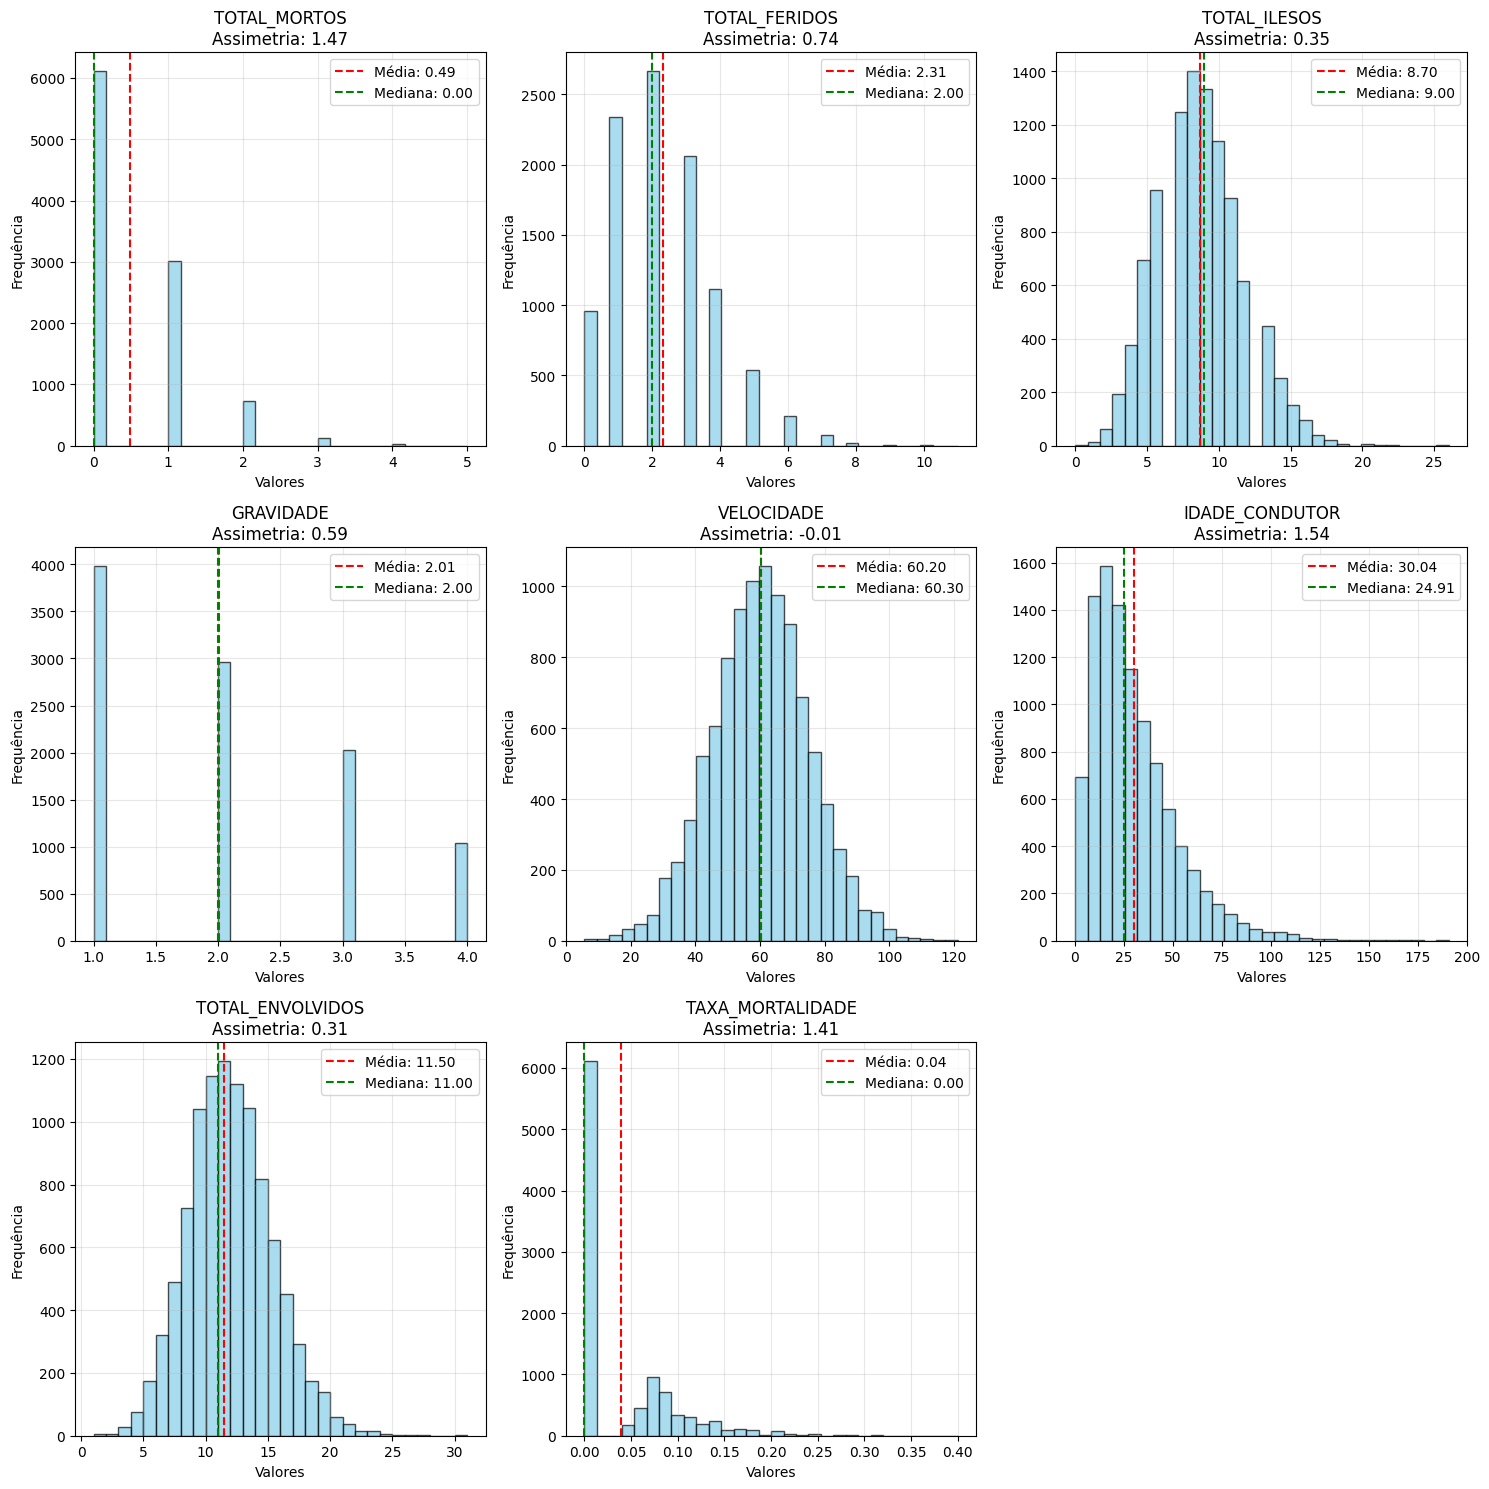

In [3]:
def calcular_estatisticas_completas(df):
    """
    Calcula todas as estatísticas descritivas solicitadas
    """
    print('📊 ESTATÍSTICAS DESCRITIVAS COMPLETAS')
    print('=' * 50)
    
    # Selecionar variáveis numéricas
    numericas = df.select_dtypes(include=[np.number])
    
    resultados = {}
    
    for coluna in numericas.columns:
        dados = df[coluna].dropna()
        
        # Medidas de tendência central
        media = dados.mean()
        mediana = dados.median()
        
        # Moda (pode ter múltiplas)
        try:
            moda = dados.mode().iloc[0] if not dados.mode().empty else np.nan
        except:
            moda = np.nan
        
        # Medidas de dispersão
        amplitude = dados.max() - dados.min()
        variancia = dados.var()
        desvio_padrao = dados.std()
        
        # Medidas de forma
        assimetria = dados.skew()
        curtose = dados.kurtosis()
        
        # Quartis
        q1 = dados.quantile(0.25)
        q3 = dados.quantile(0.75)
        iqr = q3 - q1
        
        resultados[coluna] = {
            'count': len(dados),
            'media': media,
            'mediana': mediana,
            'moda': moda,
            'amplitude': amplitude,
            'variancia': variancia,
            'desvio_padrao': desvio_padrao,
            'assimetria': assimetria,
            'curtose': curtose,
            'q1': q1,
            'q3': q3,
            'iqr': iqr,
            'min': dados.min(),
            'max': dados.max()
        }
    
    # Criar DataFrame resumo
    df_stats = pd.DataFrame(resultados).T
    
    print('📈 Resumo Estatístico:')
    display(df_stats.round(4))
    
    # Visualizações
    n_vars = len(numericas.columns)
    n_cols = 3
    n_rows = (n_vars + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.ravel() if n_vars > 1 else [axes]
    
    for i, coluna in enumerate(numericas.columns):
        if i < len(axes):
            dados = df[coluna].dropna()
            
            # Histograma com estatísticas
            axes[i].hist(dados, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
            
            # Linhas de referência
            axes[i].axvline(dados.mean(), color='red', linestyle='--', 
                           label=f'Média: {dados.mean():.2f}')
            axes[i].axvline(dados.median(), color='green', linestyle='--', 
                           label=f'Mediana: {dados.median():.2f}')
            
            axes[i].set_title(f'{coluna}\nAssimetria: {dados.skew():.2f}')
            axes[i].set_xlabel('Valores')
            axes[i].set_ylabel('Frequência')
            axes[i].legend()
            axes[i].grid(True, alpha=0.3)
    
    # Remover subplots vazios
    for i in range(n_vars, len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()
    
    return df_stats

# Executar análise
stats_completas = calcular_estatisticas_completas(df)

## 2️⃣ Análises de Correlação (Pearson e Spearman)

🔗 ANÁLISE DE CORRELAÇÕES
📊 Matriz de Correlação - Pearson:


,TOTAL_MORTOS,TOTAL_FERIDOS,TOTAL_ILESOS,GRAVIDADE,VELOCIDADE,IDADE_CONDUTOR,TOTAL_ENVOLVIDOS,TAXA_MORTALIDADE
TOTAL_MORTOS,1.000,0.024,0.006,0.001,-0.007,0.003,0.225,0.947
TOTAL_FERIDOS,0.024,1.000,-0.010,-0.008,-0.000,0.001,0.447,-0.060
TOTAL_ILESOS,0.006,-0.010,1.000,-0.009,0.003,0.009,0.865,-0.148
GRAVIDADE,0.001,-0.008,-0.009,1.000,0.006,-0.004,-0.011,0.002
VELOCIDADE,-0.007,-0.000,0.003,0.006,1.000,0.002,0.001,-0.014
IDADE_CONDUTOR,0.003,0.001,0.009,-0.004,0.002,1.000,0.009,0.000
TOTAL_ENVOLVIDOS,0.225,0.447,0.865,-0.011,0.001,0.009,1.000,0.042
TAXA_MORTALIDADE,0.947,-0.060,-0.148,0.002,-0.014,0.000,0.042,1.000



📊 Matriz de Correlação - Spearman:


,TOTAL_MORTOS,TOTAL_FERIDOS,TOTAL_ILESOS,GRAVIDADE,VELOCIDADE,IDADE_CONDUTOR,TOTAL_ENVOLVIDOS,TAXA_MORTALIDADE
TOTAL_MORTOS,1.000,0.020,-0.000,-0.000,-0.010,-0.001,0.203,0.979
TOTAL_FERIDOS,0.020,1.000,-0.010,-0.002,-0.002,-0.006,0.429,-0.036
TOTAL_ILESOS,-0.000,-0.010,1.000,-0.008,0.009,0.001,0.853,-0.106
GRAVIDADE,-0.000,-0.002,-0.008,1.000,0.007,-0.000,-0.010,0.003
VELOCIDADE,-0.010,-0.002,0.009,0.007,1.000,0.005,0.004,-0.014
IDADE_CONDUTOR,-0.001,-0.006,0.001,-0.000,0.005,1.000,-0.002,-0.001
TOTAL_ENVOLVIDOS,0.203,0.429,0.853,-0.010,0.004,-0.002,1.000,0.081
TAXA_MORTALIDADE,0.979,-0.036,-0.106,0.003,-0.014,-0.001,0.081,1.000


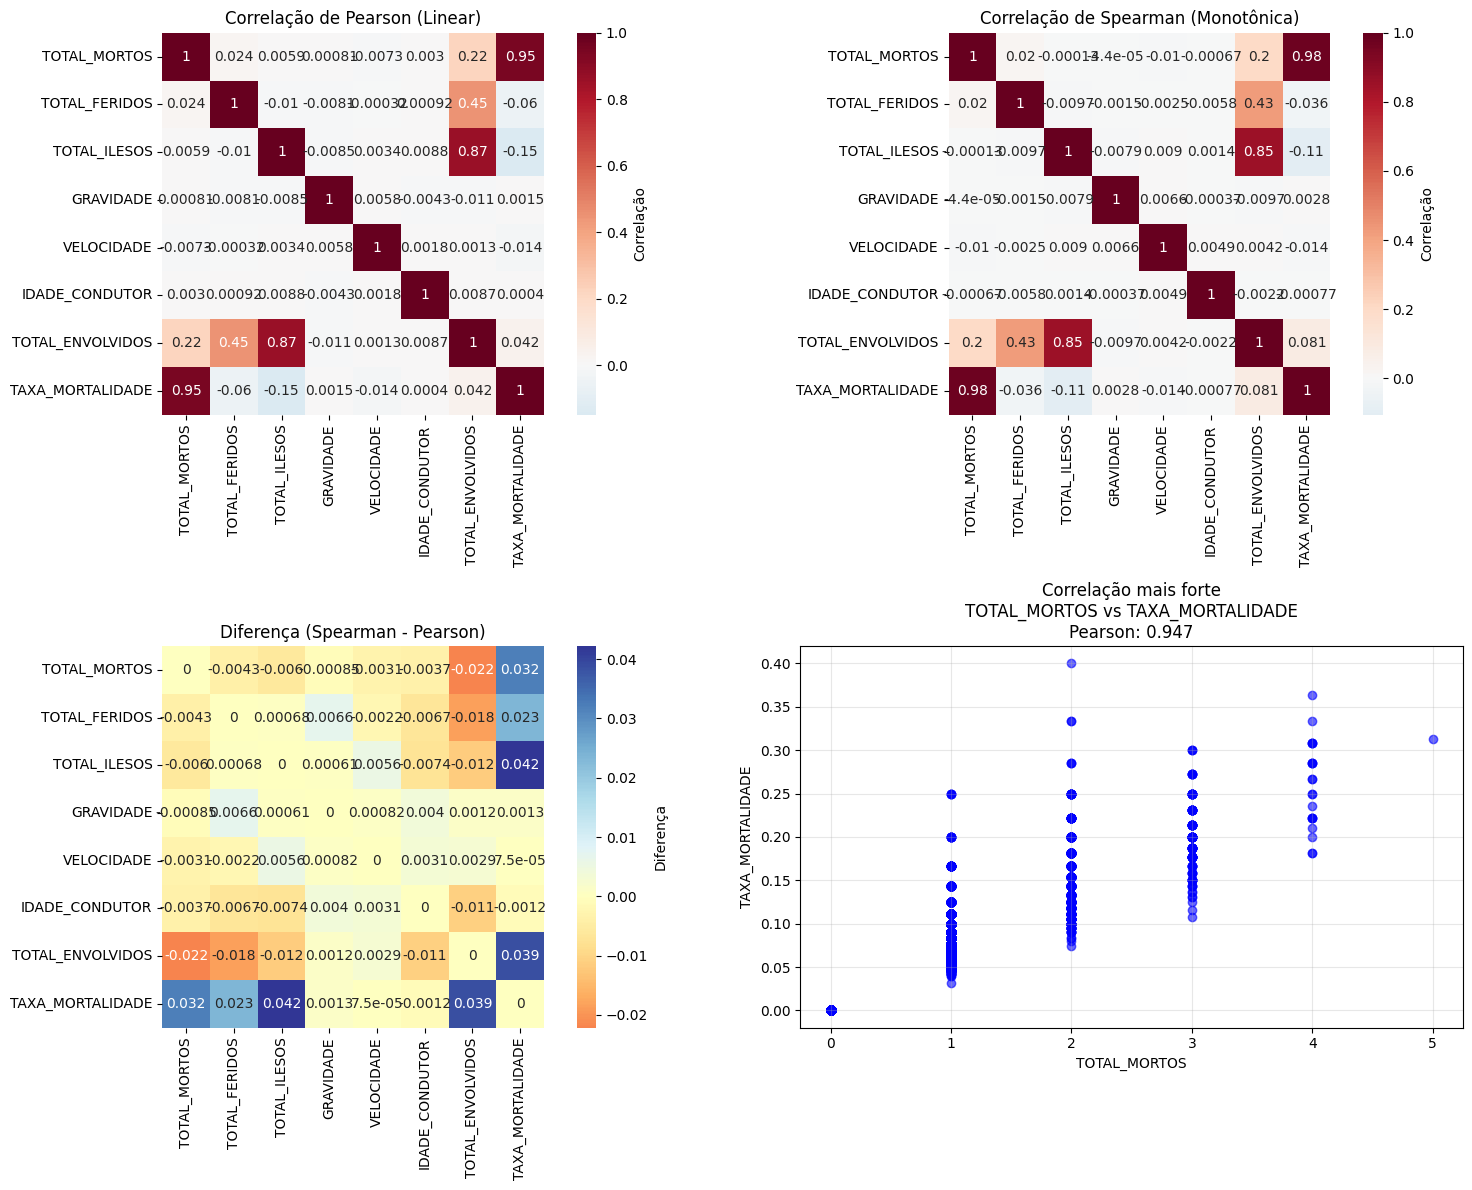


🔍 CORRELAÇÕES SIGNIFICATIVAS (|r| > 0.3):
  • TOTAL_MORTOS ↔ TAXA_MORTALIDADE:
    - Pearson: 0.947
    - Spearman: 0.979
  • TOTAL_FERIDOS ↔ TOTAL_ENVOLVIDOS:
    - Pearson: 0.447
    - Spearman: 0.429
  • TOTAL_ILESOS ↔ TOTAL_ENVOLVIDOS:
    - Pearson: 0.865
    - Spearman: 0.853


In [4]:
def analisar_correlacoes(df):
    """
    Análise completa de correlações Pearson e Spearman
    """
    print('🔗 ANÁLISE DE CORRELAÇÕES')
    print('=' * 40)
    
    # Selecionar variáveis numéricas
    numericas = df.select_dtypes(include=[np.number])
    
    # Correlação de Pearson (linear)
    corr_pearson = numericas.corr(method='pearson')
    
    # Correlação de Spearman (monotônica)
    corr_spearman = numericas.corr(method='spearman')
    
    print(f'📊 Matriz de Correlação - Pearson:')
    display(corr_pearson.round(3))
    
    print(f'\n📊 Matriz de Correlação - Spearman:')
    display(corr_spearman.round(3))
    
    # Visualizações
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # Heatmap Pearson
    sns.heatmap(corr_pearson, annot=True, cmap='RdBu_r', center=0, 
                square=True, ax=ax1, cbar_kws={'label': 'Correlação'})
    ax1.set_title('Correlação de Pearson (Linear)')
    
    # Heatmap Spearman
    sns.heatmap(corr_spearman, annot=True, cmap='RdBu_r', center=0, 
                square=True, ax=ax2, cbar_kws={'label': 'Correlação'})
    ax2.set_title('Correlação de Spearman (Monotônica)')
    
    # Diferença entre correlações
    diff_corr = corr_spearman - corr_pearson
    sns.heatmap(diff_corr, annot=True, cmap='RdYlBu', center=0, 
                square=True, ax=ax3, cbar_kws={'label': 'Diferença'})
    ax3.set_title('Diferença (Spearman - Pearson)')
    
    # Scatter plot das correlações mais fortes
    # Encontrar a correlação mais forte (excluindo diagonal)
    corr_abs = corr_pearson.abs()
    np.fill_diagonal(corr_abs.values, 0)
    
    max_corr_idx = np.unravel_index(corr_abs.values.argmax(), corr_abs.shape)
    var1 = corr_abs.index[max_corr_idx[0]]
    var2 = corr_abs.columns[max_corr_idx[1]]
    
    ax4.scatter(df[var1], df[var2], alpha=0.6, color='blue')
    ax4.set_xlabel(var1)
    ax4.set_ylabel(var2)
    ax4.set_title(f'Correlação mais forte\n{var1} vs {var2}\nPearson: {corr_pearson.loc[var1, var2]:.3f}')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Identificar correlações significativas
    print('\n🔍 CORRELAÇÕES SIGNIFICATIVAS (|r| > 0.3):')
    
    for i in range(len(corr_pearson.columns)):
        for j in range(i+1, len(corr_pearson.columns)):
            var1 = corr_pearson.columns[i]
            var2 = corr_pearson.columns[j]
            
            pearson_val = corr_pearson.iloc[i, j]
            spearman_val = corr_spearman.iloc[i, j]
            
            if abs(pearson_val) > 0.3 or abs(spearman_val) > 0.3:
                print(f'  • {var1} ↔ {var2}:')
                print(f'    - Pearson: {pearson_val:.3f}')
                print(f'    - Spearman: {spearman_val:.3f}')
                
                if abs(spearman_val - pearson_val) > 0.1:
                    print(f'    - ⚠️ Diferença significativa (possível relação não-linear)')
    
    return {
        'pearson': corr_pearson,
        'spearman': corr_spearman,
        'diferenca': diff_corr
    }

# Executar análise de correlações
correlacoes = analisar_correlacoes(df)

## 3️⃣ Técnicas de Amostragem

In [5]:
def implementar_tecnicas_amostragem(df, variavel_analise='TOTAL_FERIDOS'):
    """
    Implementa todas as técnicas de amostragem solicitadas
    """
    print('🎯 TÉCNICAS DE AMOSTRAGEM')
    print('=' * 40)
    
    if variavel_analise not in df.columns:
        variavel_analise = df.select_dtypes(include=[np.number]).columns[0]
        print(f'⚠️ Usando variável: {variavel_analise}')
    
    populacao = df[variavel_analise].dropna()
    n_amostra = min(1000, len(populacao) // 10)
    
    print(f'📊 População: {len(populacao):,} observações')
    print(f'🎯 Tamanho da amostra: {n_amostra:,}')
    print(f'📈 Variável analisada: {variavel_analise}')
    
    resultados = {}
    
    # 1. Amostragem Aleatória Simples
    print('\n1️⃣ AMOSTRAGEM ALEATÓRIA SIMPLES')
    np.random.seed(42)
    amostra_simples = populacao.sample(n=n_amostra, random_state=42)
    
    resultados['simples'] = {
        'amostra': amostra_simples,
        'media': amostra_simples.mean(),
        'desvio': amostra_simples.std(),
        'erro_padrao': amostra_simples.std() / np.sqrt(len(amostra_simples))
    }
    
    print(f'  • Média: {amostra_simples.mean():.4f}')
    print(f'  • Desvio: {amostra_simples.std():.4f}')
    print(f'  • Erro padrão: {resultados["simples"]["erro_padrao"]:.4f}')
    
    # 2. Amostragem Sistemática
    print('\n2️⃣ AMOSTRAGEM SISTEMÁTICA')
    k = len(populacao) // n_amostra  # Intervalo
    inicio = np.random.randint(0, k)
    indices_sistematicos = list(range(inicio, len(populacao), k))[:n_amostra]
    amostra_sistematica = populacao.iloc[indices_sistematicos]
    
    resultados['sistematica'] = {
        'amostra': amostra_sistematica,
        'media': amostra_sistematica.mean(),
        'desvio': amostra_sistematica.std(),
        'erro_padrao': amostra_sistematica.std() / np.sqrt(len(amostra_sistematica)),
        'intervalo': k
    }
    
    print(f'  • Intervalo (k): {k}')
    print(f'  • Início: {inicio}')
    print(f'  • Média: {amostra_sistematica.mean():.4f}')
    print(f'  • Desvio: {amostra_sistematica.std():.4f}')
    
    # 3. Amostragem Estratificada
    print('\n3️⃣ AMOSTRAGEM ESTRATIFICADA')
    
    # Usar uma variável categórica para estratificar
    if 'ESTADO' in df.columns:
        estrato_var = 'ESTADO'
    elif 'REGIAO' in df.columns:
        estrato_var = 'REGIAO'
    else:
        # Criar estratos baseados em quartis
        df['QUARTIL'] = pd.qcut(df[variavel_analise], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
        estrato_var = 'QUARTIL'
    
    amostras_estratos = []
    info_estratos = []
    
    for estrato in df[estrato_var].unique():
        if pd.isna(estrato):
            continue
            
        dados_estrato = df[df[estrato_var] == estrato][variavel_analise].dropna()
        
        if len(dados_estrato) > 0:
            # Amostragem proporcional
            prop = len(dados_estrato) / len(populacao)
            n_estrato = max(1, int(n_amostra * prop))
            
            if n_estrato <= len(dados_estrato):
                amostra_estrato = dados_estrato.sample(n=n_estrato, random_state=42)
                amostras_estratos.append(amostra_estrato)
                
                info_estratos.append({
                    'estrato': estrato,
                    'populacao': len(dados_estrato),
                    'amostra': len(amostra_estrato),
                    'proporcao': prop,
                    'media': amostra_estrato.mean()
                })
    
    amostra_estratificada = pd.concat(amostras_estratos) if amostras_estratos else pd.Series()
    
    if not amostra_estratificada.empty:
        resultados['estratificada'] = {
            'amostra': amostra_estratificada,
            'media': amostra_estratificada.mean(),
            'desvio': amostra_estratificada.std(),
            'erro_padrao': amostra_estratificada.std() / np.sqrt(len(amostra_estratificada)),
            'estratos': info_estratos
        }
        
        print(f'  • Variável de estratificação: {estrato_var}')
        print(f'  • Número de estratos: {len(info_estratos)}')
        print(f'  • Tamanho total da amostra: {len(amostra_estratificada)}')
        print(f'  • Média estratificada: {amostra_estratificada.mean():.4f}')
        
        for info in info_estratos:
            print(f'    - {info["estrato"]}: {info["amostra"]} obs (média: {info["media"]:.2f})')
    
    # 4. Amostragem por Conglomerados
    print('\n4️⃣ AMOSTRAGEM POR CONGLOMERADOS')
    
    # Criar conglomerados artificiais (grupos de 50 observações)
    tamanho_conglomerado = 50
    n_conglomerados_total = len(populacao) // tamanho_conglomerado
    n_conglomerados_amostra = max(1, n_amostra // tamanho_conglomerado)
    
    # Selecionar conglomerados aleatoriamente
    conglomerados_selecionados = np.random.choice(
        range(n_conglomerados_total), 
        size=n_conglomerados_amostra, 
        replace=False
    )
    
    indices_conglomerados = []
    for c in conglomerados_selecionados:
        inicio = c * tamanho_conglomerado
        fim = min((c + 1) * tamanho_conglomerado, len(populacao))
        indices_conglomerados.extend(range(inicio, fim))
    
    amostra_conglomerados = populacao.iloc[indices_conglomerados]
    
    resultados['conglomerados'] = {
        'amostra': amostra_conglomerados,
        'media': amostra_conglomerados.mean(),
        'desvio': amostra_conglomerados.std(),
        'erro_padrao': amostra_conglomerados.std() / np.sqrt(len(amostra_conglomerados)),
        'n_conglomerados': n_conglomerados_amostra,
        'tamanho_conglomerado': tamanho_conglomerado
    }
    
    print(f'  • Conglomerados selecionados: {n_conglomerados_amostra}')
    print(f'  • Tamanho por conglomerado: {tamanho_conglomerado}')
    print(f'  • Tamanho total da amostra: {len(amostra_conglomerados)}')
    print(f'  • Média: {amostra_conglomerados.mean():.4f}')
    
    return resultados

# Executar técnicas de amostragem
resultados_amostragem = implementar_tecnicas_amostragem(df)

🎯 TÉCNICAS DE AMOSTRAGEM
📊 População: 10,000 observações
🎯 Tamanho da amostra: 1,000
📈 Variável analisada: TOTAL_FERIDOS

1️⃣ AMOSTRAGEM ALEATÓRIA SIMPLES
  • Média: 2.2570
  • Desvio: 1.5746
  • Erro padrão: 0.0498

2️⃣ AMOSTRAGEM SISTEMÁTICA
  • Intervalo (k): 10
  • Início: 6
  • Média: 2.2820
  • Desvio: 1.4929

3️⃣ AMOSTRAGEM ESTRATIFICADA
  • Variável de estratificação: ESTADO
  • Número de estratos: 5
  • Tamanho total da amostra: 998
  • Média estratificada: 2.2455
    - RS: 200 obs (média: 2.15)
    - PR: 202 obs (média: 2.28)
    - RJ: 204 obs (média: 2.26)
    - MG: 193 obs (média: 2.45)
    - SP: 199 obs (média: 2.09)

4️⃣ AMOSTRAGEM POR CONGLOMERADOS
  • Conglomerados selecionados: 20
  • Tamanho por conglomerado: 50
  • Tamanho total da amostra: 1000
  • Média: 2.3190
